# Effective connectivity in the NETSIM dataset

# Analyzing results from the estimation procedure for the NETSIM dataset

Recall that our experiments also included several lengths of the original time series. All these results are grouped into a separate folder inside a big directory for every simulation.
The relevant directories as defined below and can be easily retrieved as follows:

In [11]:
simulations = [1, 7, 15, 19, 28]
lengths = [70, 75, 80, 85, 90, 95, 100]
main_dir = lambda sim: f"Results_Netsim-Dataset_Sim-{sim}"
length_dir = lambda length, sim: f"/Results_Dataset-Netsim_Sim-{sim}_Length-{length}"

We import the relevant methods from the submodules in the code. For the specific case of Netsim, we provide a convenient wrapper class that contains the necessary utilities. All of these utilities however can be found independently in the code and used for your own dataset.

In [12]:
from analysis.ground_truths.netsim import Netsim
simulation_number = 7
netsim_results = Netsim(
    f"Results_Netsim-Dataset_Sim-{simulation_number}/Results_Dataset-Netsim_Sim-{simulation_number}_Length-100",
    simulation=simulation_number
)
N_subjects = len(netsim_results.subject_list)

# Lets specify the weighted and binary ground truths
w_ground_truths, b_ground_truth = netsim_results.weighted_gts, netsim_results.binary_gt

In [13]:
# Load the reconstructed networks for each subject
binary_networks = netsim_results.get_networks_Adjacency(weighted=False, bidirectional=False, save_in=False)
weighted_networks = netsim_results.get_networks_Adjacency(weighted=True, bidirectional=False, save_in=False)

In [14]:
# We can access a particular time lag and subject if we wish to
example_lag = -1
example_subject = f"sub-50_sim-{simulation_number}_Length-100_Method-RCC"
example_subject_ID = netsim_results.subjects[example_subject]
example_network_b = binary_networks[example_lag][example_subject_ID]
example_network_w = weighted_networks[example_lag][example_subject_ID]

print("Ground truth:")
print(b_ground_truth)
print("Reconstructed binary network for the example subject")
print(example_network_b)
print("Reconstructed weighted network for the example subject")
print(example_network_w)

Ground truth:
[[0. 1. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
Reconstructed binary network for the example subject
[[0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]]
Reconstructed weighted network for the example subject
[[0.00000000e+00 9.99999981e-01 4.73994343e-05 9.99803092e-01
  2.76840784e-03]
 [1.86776392e-08 0.00000000e+00 9.96329325e-01 7.81804649e-01
  7.29253005e-03]
 [9.99952601e-01 3.67067480e-03 0.00000000e+00 1.00000000e+00
  1.00000000e+00]
 [1.94563144e-04 2.18195351e-01 0.00000000e+00 0.00000000e+00
  1.23476394e-01]
 [9.97231592e-01 9.92707470e-01 1.15323306e-11 8.76523606e-01
  0.00000000e+00]]


100%|██████████| 50/50 [00:01<00:00, 49.86it/s]


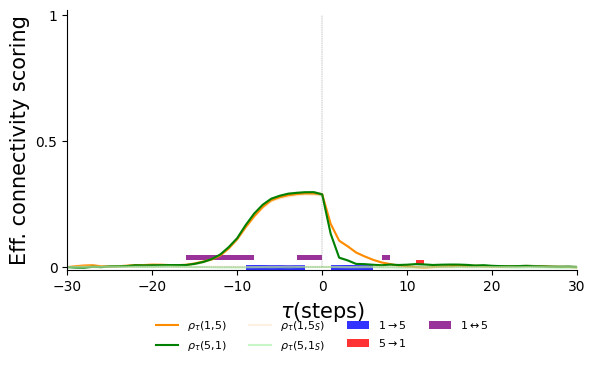

In [17]:
netsim_results.plot_interaction_ij(1,5)

100%|██████████| 50/50 [00:00<00:00, 52.94it/s]


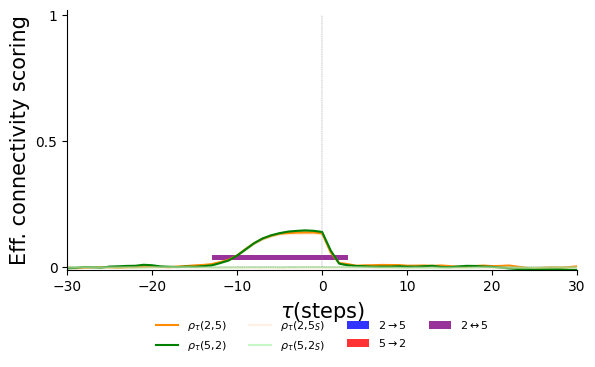

In [18]:
netsim_results.plot_interaction_ij(2,5)

100%|██████████| 50/50 [00:00<00:00, 51.30it/s]


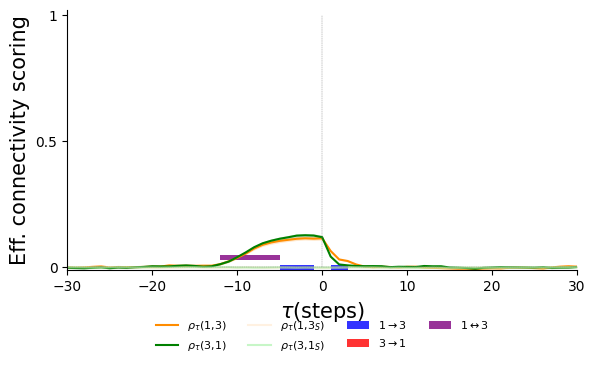

In [19]:
netsim_results.plot_interaction_ij(1,3)

### Accuracies of the reconstructions

To study the goodness of the reconstructions we constrain the networks to the k-th neighbor interactions. For that, we employ the methods found in the analysis.utils.Constraints class (already available within the Netsim wrapper). The motivation for this is to be able to study first, second, ... interactions within a system with a known physical structure. We wish to be able to disentangle typical network motifs present in complex systems (e.g., common cause, indirect causation).

In [5]:
import numpy as np

k_neighbor = 1
predictions_b_k, gts_k = netsim_results.constrain_datset(binary_networks)
predictions_w_k, _ = netsim_results.constrain_datset(weighted_networks)

# The real network remains unaltered through time, but this is not necessarily true for every system. 
gts_k = gts_k[-1]
all_gts_k = np.tile(gts_k, N_subjects) # ground truths: [gt, gt, gt, ...]

all_lags = list(predictions_b_k.keys())
N_lags = len(all_lags)

We now have all the data loaded into a compact python object. There is still a lot of data however to go through. One of the advantages is that the predictions are stored in an iterable object and that the temporal lag is uniquely identified by its value.

The next step is to load and compute the metrics that we are going to evaluate. Appropriate statistical procedures are also readily available: Bootstrapping, ROC analyses, DET analyses and DeLong.

In [100]:
from analysis.ground_truths.utils import Metrics

classification_metrics = dict()
classification_metrics_all = dict()

for i, lag in enumerate(all_lags):
    if lag != 0.0:
        # Option 1: we treat each network as an independent test set
        classification_metrics[lag] = Metrics(
            gts_k, weighted_predictions=predictions_w_k[lag], binary_predictions=predictions_b_k[lag]
        )

        # option 2: We pool all the subjects together and consider a unique testing set
        classification_metrics_all[lag] = Metrics(
            all_gts_k,                                           # Ground truths: [gt, gt, gt, ...]
            weighted_predictions=predictions_w_k[lag].flatten(), # Predictions: [weighted_net1, weighted_net2, weighted_net3, ...]
            binary_predictions=predictions_b_k[lag].flatten()    # Predictions: [binary_net1, binary_net2, binary_net3, ...]
        )

### Area Under the Receiver Operating Curve

In [108]:
# Execution time: around 2 minutes

auc_lags = np.zeros((N_lags, N_subjects))
ppv_lag = np.zeros((N_lags, N_subjects))
npv_lag = np.zeros((N_lags, N_subjects)) 
auc_lags_all = np.zeros((N_lags, N_subjects))
ppv_lag_all = np.zeros((N_lags, N_subjects))
npv_lag_all = np.zeros((N_lags, N_subjects)) 

for i, lag in enumerate(all_lags):
    if lag != 0.0:
        # Option 1: Allows us to compute (non)-parametric stats
        auc_lags[i,:] = classification_metrics[lag].auc()
        _, _, ppv_lag[i,:], npv_lag[i,:] = classification_metrics[lag].compute_confusion_matrix()

        # Option 2: Allows us to compute confidence intervals by bootstrapping
        auc_lags_all[i,:] = classification_metrics_all[lag].auc(n_bootstrap=1000)
        ppv_lag_all[i,:] = classification_metrics_all[lag].positive_predictive_value(n_bootstrap=1000)
        npv_lag_all[i,:]  = classification_metrics_all[lag].negative_predicitive_value(n_bootstrap=1000)
    else:
        auc_lags[i,:], auc_lags_all[i,:] = np.nan, np.nan
        ppv_lag[i,:], ppv_lag_all[i,:] = np.nan, np.nan
        npv_lag[i,:], npv_lag_all[i,:] = np.nan, np.nan

/tmp/ipykernel_1018288/2221201138.py:3: RuntimeWarning: Mean of empty slice
  plt.plot(all_lags, np.nanmean(auc_lags_all, axis=-1))
/tmp/ipykernel_1018288/2221201138.py:4: RuntimeWarning: Mean of empty slice
  plt.plot(all_lags, np.nanmean(auc_lags, axis=-1))


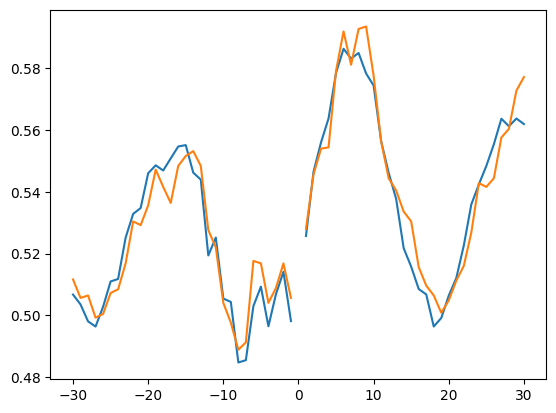

In [110]:
import matplotlib.pylab as plt

plt.plot(all_lags, np.nanmean(auc_lags_all, axis=-1))
plt.plot(all_lags, np.nanmean(auc_lags, axis=-1))

In [ ]:
from analysis.stats import ROC_utils

ROC = ROC_utils(all_predictions_w_k, all_gts_k)
ROC_BOOTSTRAPPED = ROC.bootstrap_roc(resolution=0.01)

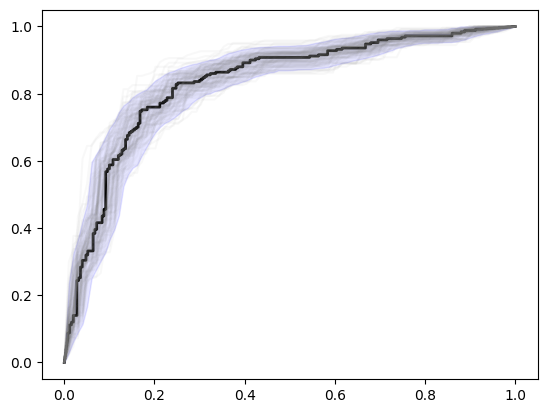

In [ ]:
import matplotlib.pylab as plt
plt.plot(ROC.fpr_real, ROC.tpr_real, c="black", linewidth=2)
#plt.fill_between(ROC_BOOTSTRAPPED.fpr, ROC_BOOTSTRAPPED.CI__parametric__true_value[1], ROC_BOOTSTRAPPED.CI__parametric__true_value[0], color="gray", alpha=0.5)
#plt.fill_between(ROC_BOOTSTRAPPED.fpr, ROC_BOOTSTRAPPED.CI__nonparametric__sorted_tprates[1], ROC_BOOTSTRAPPED.CI__nonparametric__sorted_tprates[0], color="gray", alpha=0.25)
plt.fill_between(ROC_BOOTSTRAPPED.fpr, ROC_BOOTSTRAPPED.CI.nonparametric.sorted_tprates[1], ROC_BOOTSTRAPPED.CI.nonparametric.sorted_tprates[0], color="blue", alpha=0.1)
for i in range(100):
    plt.plot(ROC_BOOTSTRAPPED.fpr, ROC_BOOTSTRAPPED.tpr[i], alpha=0.05, c="gray")

In [ ]:
ROC.mean_boot

array([0.8067869 , 1.        , 1.        , 0.58998889, 0.5973369 ,
       0.40178889, 1.        , 0.59023929, 0.40060516, 0.59707579,
       1.        , 0.60446032, 0.59633056, 0.8136754 , 0.79386746,
       0.78984008, 0.20149802, 0.3964127 , 1.        , 0.58376468,
       0.59579008, 0.39215992, 0.80501905, 0.60287817, 0.60059524,
       0.60696905, 1.        , 0.20688294, 0.59975357, 0.60095595,
       0.1996627 , 0.79343294, 0.5805623 , 1.        , 0.40191389,
       0.39418889, 0.60618611, 0.60408532, 0.59917698, 1.        ,
       0.20274008, 0.81011786, 0.59367262, 0.80044087, 0.59023611,
       0.80691984, 0.6017373 , 0.40326667, 1.        , 1.        ])